In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import tqdm
import helpers

import environments
import environments.bicycle as bicycle

import controllers.stanley as stanley
import controllers.clothoids as clothoids
import controllers.purepursuit as purepursuit
import controllers.dqn as dqn

import metrics

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

/Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            width=40.0,
            turn_radius=8.0,
            lane_config=bicycle.lane_config_from_width(8.0, num_lanes=1),
        )
    ]),
    render_mode="rgb_array",
    world_size=(100.0, 100.0),
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

In [4]:
controller = clothoids.ClothoidTentaclesController(
    num_tentacles=41,
    # t0=7.0,
    t0=10.0,
    # l0=5.0,
    l0=10.0,
    num_points_per_tentacle=64,

    wheelbase=1.75,
    vehicle_width=1.8,
    max_lateral_acceleration=4.0,
    max_deceleration=1.5,

    weight_clearance=0.1,
    weight_curvature=0.2,
    weight_trajectory=0.5,

    target_velocity=5.0,
    kp_velocity=2.0,
)

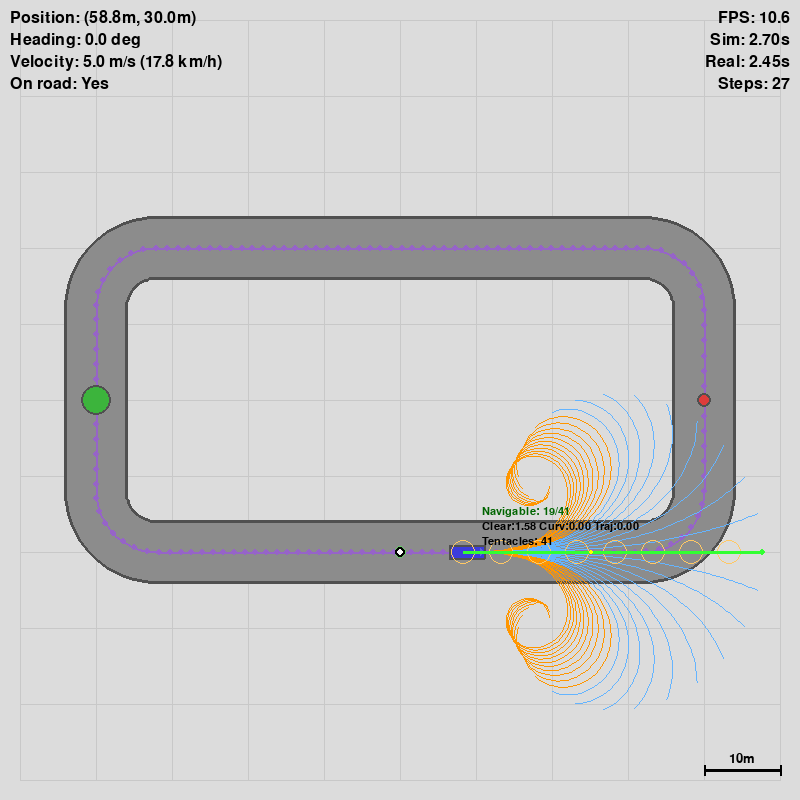

KeyboardInterrupt: 

In [8]:
obs, info = env.reset()

for i in range(500):
    action = controller.get_action(
        observation=obs,
        path=env.global_path,
        obstacles=env.obstacles,
        road_network=env.road_network,
        max_steering=env.MAX_STEERING,
        max_acceleration=env.MAX_ACCELERATION,
    )
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.overlay_manager.clear()
    controller.draw_debug(env, obs, env.global_path)
    
    helpers.preview(env)

    if terminated or truncated:
        break

env.close()

In [ ]:
# Get episode data and compute metrics
episode_data = env.get_episode_data()
# print(f"Episode finished after {i+1} steps")

# Compute metrics
print("\n=== Performance Metrics ===")

cte_metrics = metrics.compute_cross_track_error(
    positions=episode_data['positions'],
    reference_path=env.global_path,
)
print(f"CTE RMS: {cte_metrics['cte_rms']:.3f} m")

smoothness_metrics = metrics.compute_steering_smoothness(
    steering_angles=episode_data['steering_angles'],
    dt=env.dt,
)
print(f"Steering Jerk RMS: {smoothness_metrics['steering_jerk_rms']:.3f} rad/s³")

success = metrics.compute_success_rate([episode_data])
print(f"Success: {'Yes' if success == 1.0 else 'No'}")

In [5]:
# Create DQN controller and train
dqn_controller = dqn.DQNController(
    n_steering=5,           # 5 steering bins: [-45°, -22.5°, 0°, 22.5°, 45°]
    n_accel=3,              # 3 accel bins: [decel, coast, accel]
    accel_values=(0.3, 0.5, 0.7),
    target_velocity=5.0,
    # DQN hyperparameters
    learning_rate=1e-4,
    buffer_size=50_000,
    learning_starts=500,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
)

# Train on the environment
dqn_controller = dqn_controller.train(
    env=env,
    total_timesteps=20_000,  # Start with 20k for quick test, increase for better results
    log_interval=10,
    progress_bar=True,
    verbose=1,
)

Using cpu device
Wrapping the env in a DummyVecEnv.


/Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 37.7     |
|    ep_rew_mean      | 36.2     |
|    exploration_rate | 0.94     |
| time/               |          |
|    episodes         | 10       |
|    fps              | 2154     |
|    time_elapsed     | 0        |
|    total_timesteps  | 377      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.4     |
|    ep_rew_mean      | 37.2     |
|    exploration_rate | 0.879    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 1851     |
|    time_elapsed     | 0        |
|    total_timesteps  | 767      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.782    |
|    n_updates        | 66       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

In [ ]:
# Save the trained model
dqn_controller.save("models/dqn_lane_following")

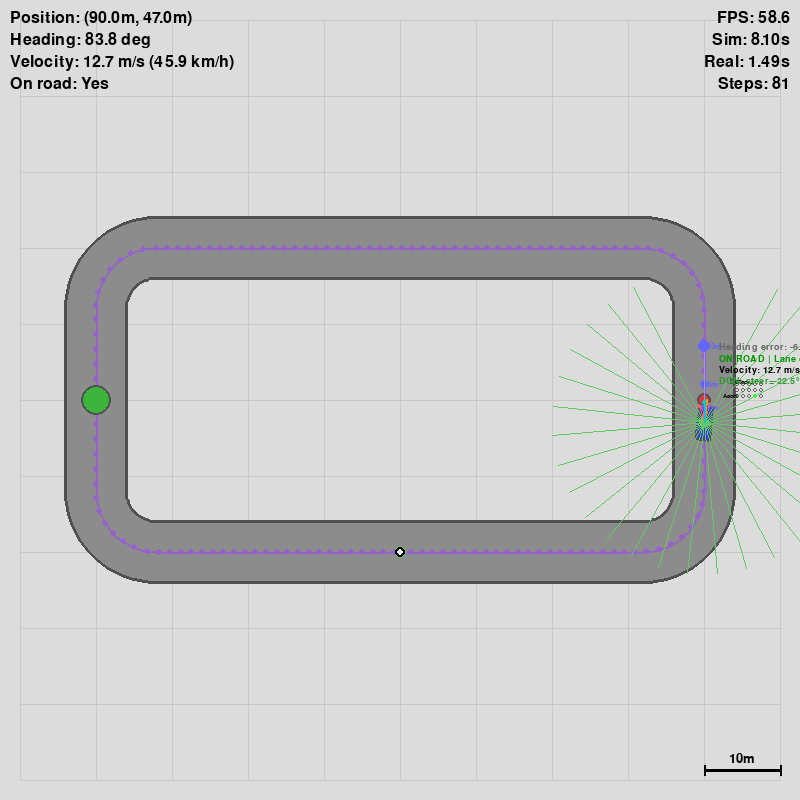

Episode finished after 81 steps

=== Performance Metrics ===
CTE RMS: 0.603 m
CTE Mean: 0.494 m
CTE Max: 1.296 m

Steering Jerk RMS: 889.288 rad/s³
Steering Jerk Mean: 553.806 rad/s³
Steering Jerk Max: 2356.195 rad/s³

Success: No (0.0%)


: 

In [ ]:
# Test the trained DQN controller (same interface as other controllers)
obs, info = env.reset()

for i in range(250):
    action = dqn_controller.get_action(
        observation=obs,
        path=env.global_path,
        obstacles=env.obstacles,
        road_network=env.road_network,
        max_steering=env.max_steering,
        max_acceleration=env.max_acceleration,
    )
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.overlay_manager.clear()
    dqn_controller.draw_debug(env, obs, env.global_path)
    
    helpers.preview(env)

    if terminated or truncated:
        break

env.close()
print(f"Episode finished after {i+1} steps")

# Get episode data from environment
episode_data = env.get_episode_data()

# Compute metrics
print("\n=== Performance Metrics ===")

# Cross-Track Error
cte_metrics = metrics.compute_cross_track_error(
    positions=episode_data['positions'],
    reference_path=env.global_path,
)
print(f"CTE RMS: {cte_metrics['cte_rms']:.3f} m")
print(f"CTE Mean: {cte_metrics['cte_mean']:.3f} m")
print(f"CTE Max: {cte_metrics['cte_max']:.3f} m")

# Steering Smoothness
smoothness_metrics = metrics.compute_steering_smoothness(
    steering_angles=episode_data['steering_angles'],
    dt=env.dt,
)
print(f"\nSteering Jerk RMS: {smoothness_metrics['steering_jerk_rms']:.3f} rad/s³")
print(f"Steering Jerk Mean: {smoothness_metrics['steering_jerk_mean']:.3f} rad/s³")
print(f"Steering Jerk Max: {smoothness_metrics['steering_jerk_max']:.3f} rad/s³")

# Success Rate (for single episode)
success = metrics.compute_success_rate([episode_data])
print(f"\nSuccess: {'Yes' if success == 1.0 else 'No'} ({success:.1%})")